# HDD/CDD Calculation for 4 Climate Scenarios (SSP1/SSP2/SSP3/SSP5), 2025–2060

The existing `chdd_calculation.ipynb` only produces **one** HDD/CDD projection path (RCP4.5,
CCLM4-8-17/MPI-ESM-LR, bias-adjusted vs ERA5, continuous 1950–2100). That single path is what
`data_preparation.ipynb` currently writes into `panel.csv` / `panel_transformed.csv` for **all**
years, historical and future alike.

This notebook builds **four additional, scenario-specific** HDD/CDD projection paths for
2025–2060, one per SSP marker, using the raw hourly 2m-temperature data downloaded from
Copernicus (`Data - raw/chdd_data/Copernicus Data - Fabian/`, PECD v4.2, CMIP6 MPI-ESM1-2-HR).
Unlike the original RCP4.5 files, Copernicus only provided **raw temperature**, not
precomputed degree days, for this data — so HDD/CDD are derived here from hourly temperature.

**Scenario mapping** (climate marker → SSP → matching heat-pump-adoption scenario used in
`heat_pump_ols.ipynb`'s `SCENARIOS` dict):

| File marker | SSP  | HP-adoption scenario |
|-------------|------|-----------------------|
| SP126       | SSP1 | KKO                   |
| SP245       | SSP2 | KVE                   |
| SP370       | SSP3 | VNI                   |
| SP585       | SSP5 | VWE                   |

**Degree-day formula.** Following the same methodology used to produce the original CDS
`03_heating_degree_days` / `04_cooling_degree_days` products (per the C3S/EEA *Heating and
Cooling Degree Days* application user guide v0.9, §3.6.1, "the Toolbox tools implement the
formulas defined by Spinoni"), daily HDD/CDD are computed from the daily maximum, average and
minimum temperature as:

```
          | Tbase - Tavg                              if Tbase >= Tmax
HDD_day = | (Tbase-Tmin)/2 - (Tmax-Tbase)/4            if Tavg <= Tbase < Tmax
          | (Tbase-Tmin)/4                             if Tmin <= Tbase < Tavg
          | 0                                          if Tbase <= Tmin

          | 0                                          if Tbase >= Tmax
CDD_day = | (Tmax-Tbase)/4                             if Tavg <= Tbase < Tmax
          | (Tmax-Tbase)/2 - (Tbase-Tmin)/4             if Tmin <= Tbase < Tavg
          | Tavg - Tbase                                if Tbase <= Tmin
```

with `Tbase = 15.5°C` for HDD and `Tbase = 22°C` for CDD. Annual HDD/CDD = sum of the daily
values over the calendar year. Tmin/Tmax/Tavg are computed here from the raw **hourly** data
(finer than the 3-hourly data the CDS Toolbox itself uses — the app's own validation section
notes the hourly-vs-3-hourly difference is negligible, ~0.1°C).

**Caveat (documented, not corrected):** this SSP-based path (MPI-ESM1-2-HR, PECD v4.2, no
ERA5 bias-adjustment mentioned) starts only in 2025 and comes from a different model chain than
the continuous RCP4.5 series used for 1990–2024. Spliced directly at the 2024/2025 boundary,
the four scenario paths may show a level jump relative to the historical series. The raw,
un-adjusted scenario values are used as-is (per instruction), so this discontinuity is not
corrected here.


In [1]:
import glob
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Country mapping and EU-26 filter

Same mapping used in `chdd_calculation.ipynb`, so the resulting `country` names line up exactly with the `countries` list in `data_preparation.ipynb`.

In [2]:
# NOTE: Greece uses Eurostat code 'EL', not ISO 'GR'
NUTS_TO_COUNTRY = {
    'AT': 'Austria',     'BE': 'Belgium',      'BG': 'Bulgaria',
    'HR': 'Croatia',     'CZ': 'Czechia',      'DK': 'Denmark',
    'EE': 'Estonia',     'FI': 'Finland',      'FR': 'France',
    'DE': 'Germany',     'EL': 'Greece',       'HU': 'Hungary',
    'IE': 'Ireland',     'IT': 'Italy',        'LV': 'Latvia',
    'LT': 'Lithuania',   'LU': 'Luxembourg',   'NL': 'Netherlands',
    'NO': 'Norway',      'PL': 'Poland',       'PT': 'Portugal',
    'RO': 'Romania',     'SK': 'Slovakia',     'SI': 'Slovenia',
    'ES': 'Spain',       'SE': 'Sweden',
}

EU26 = set(NUTS_TO_COUNTRY.keys())

RAW_DIR = "Copernicus Data - Fabian"
OUTPUT_DIR = "output_csv"
os.makedirs(OUTPUT_DIR, exist_ok=True)


## Scenario metadata

Maps each Copernicus file marker (`SPxxx`) to its SSP label and to the matching heat-pump-adoption scenario abbreviation used in `heat_pump_ols.ipynb`.

In [3]:
SCENARIO_INFO = {
    "SP126": {"ssp": "SSP1", "hp_scenario": "KKO"},
    "SP245": {"ssp": "SSP2", "hp_scenario": "KVE"},
    "SP370": {"ssp": "SSP3", "hp_scenario": "VNI"},
    "SP585": {"ssp": "SSP5", "hp_scenario": "VWE"},
}

HDD_TBASE = 15.5   # deg C
CDD_TBASE = 22.0   # deg C

FILENAME_RE = re.compile(r"_S(\d{4})\d{8}_E\d{12}_.*_(SP\d{3})_")


## Reading one hourly-temperature file into daily Tmin/Tmax/Tavg per country

In [4]:
def read_hourly_temperature(path):
    """Reads one Copernicus hourly 2m-temperature CSV, skipping the metadata header,
    and returns a long-format DataFrame with one row per (nuts0, date) giving the
    daily min/mean/max temperature (deg C)."""

    with open(path, "r") as f:
        for i, line in enumerate(f):
            if line.startswith("Date,"):
                header_line = i
                columns = line.strip().split(",")
                break

    eu26_cols = [c for c in columns if c in EU26]
    usecols = ["Date"] + eu26_cols

    df = pd.read_csv(path, skiprows=header_line, usecols=usecols)
    df["Date"] = pd.to_datetime(df["Date"])
    df["date"] = df["Date"].dt.date

    long_df = df.melt(id_vars=["date"], value_vars=eu26_cols,
                       var_name="nuts0", value_name="tempC")

    daily = (
        long_df.groupby(["nuts0", "date"])["tempC"]
        .agg(tmin="min", tmax="max", tavg="mean")
        .reset_index()
    )
    daily["year"] = pd.to_datetime(daily["date"]).dt.year
    return daily


## Spinoni daily HDD/CDD formula (vectorized)

In [5]:
def compute_daily_degree_days(tmin, tmax, tavg, tbase):
    """Vectorized Spinoni daily HDD/CDD split for one threshold Tbase.
    Returns (hdd_day, cdd_day) arrays."""

    tmin = np.asarray(tmin, dtype=float)
    tmax = np.asarray(tmax, dtype=float)
    tavg = np.asarray(tavg, dtype=float)

    cond1 = tbase >= tmax
    cond2 = (tavg <= tbase) & (tbase < tmax)
    cond3 = (tmin <= tbase) & (tbase < tavg)
    cond4 = tbase <= tmin

    hdd = np.select(
        [cond1, cond2, cond3, cond4],
        [
            tbase - tavg,
            (tbase - tmin) / 2 - (tmax - tbase) / 4,
            (tbase - tmin) / 4,
            0.0,
        ],
        default=0.0,
    )
    cdd = np.select(
        [cond1, cond2, cond3, cond4],
        [
            0.0,
            (tmax - tbase) / 4,
            (tmax - tbase) / 2 - (tbase - tmin) / 4,
            tavg - tbase,
        ],
        default=0.0,
    )

    # numerical safety net: HDD/CDD are physically non-negative
    return np.clip(hdd, 0, None), np.clip(cdd, 0, None)


## Main loop: read all 48 files (12 years × 4 scenarios), aggregate to annual HDD/CDD

In [6]:
files = sorted(glob.glob(os.path.join(RAW_DIR, "*.csv")))
print(f"Found {len(files)} Copernicus files")

annual_rows = []

for path in files:
    fname = os.path.basename(path)
    m = FILENAME_RE.search(fname)
    if m is None:
        print(f"  WARNING: filename pattern not recognized, skipping: {fname}")
        continue
    file_year, sp_code = m.group(1), m.group(2)
    if sp_code not in SCENARIO_INFO:
        print(f"  WARNING: unknown scenario marker {sp_code}, skipping: {fname}")
        continue

    daily = read_hourly_temperature(path)

    hdd_day, cdd_day = compute_daily_degree_days(
        daily["tmin"], daily["tmax"], daily["tavg"], HDD_TBASE
    )
    daily["hdd_day"] = hdd_day
    _, cdd_day2 = compute_daily_degree_days(
        daily["tmin"], daily["tmax"], daily["tavg"], CDD_TBASE
    )
    daily["cdd_day"] = cdd_day2

    annual = (
        daily.groupby(["nuts0", "year"])
        .agg(hdd_annual=("hdd_day", "sum"),
             cdd_annual=("cdd_day", "sum"),
             tas_annual=("tavg", "mean"))
        .reset_index()
    )

    info = SCENARIO_INFO[sp_code]
    annual["sp_code"] = sp_code
    annual["ssp"] = info["ssp"]
    annual["scenario"] = info["hp_scenario"]

    annual_rows.append(annual)
    print(f"  {fname}: {len(daily)} country-days -> {len(annual)} country rows "
          f"(year {file_year}, {sp_code}/{info['ssp']}/{info['hp_scenario']})")

hdd_cdd_scenarios = pd.concat(annual_rows, ignore_index=True)
hdd_cdd_scenarios["country"] = hdd_cdd_scenarios["nuts0"].map(NUTS_TO_COUNTRY)

hdd_cdd_scenarios = hdd_cdd_scenarios[
    ["scenario", "ssp", "sp_code", "nuts0", "country", "year",
     "hdd_annual", "cdd_annual", "tas_annual"]
].sort_values(["scenario", "country", "year"]).reset_index(drop=True)

print(f"\nShape: {hdd_cdd_scenarios.shape}")
print(f"Years: {sorted(hdd_cdd_scenarios.year.unique())}")
print(f"Scenarios: {sorted(hdd_cdd_scenarios.scenario.unique())}")
print(f"Countries ({hdd_cdd_scenarios.country.nunique()}): {sorted(hdd_cdd_scenarios.country.unique())}")
hdd_cdd_scenarios.head(10)


Found 48 Copernicus files
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S202501010000_E202512312300_INS_TIM_01h_NA-_cdf_org_NA_SP126_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2025, SP126/SSP1/KKO)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S202501010000_E202512312300_INS_TIM_01h_NA-_cdf_org_NA_SP245_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2025, SP245/SSP2/KVE)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S202501010000_E202512312300_INS_TIM_01h_NA-_cdf_org_NA_SP370_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2025, SP370/SSP3/VNI)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S202501010000_E202512312300_INS_TIM_01h_NA-_cdf_org_NA_SP585_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2025, SP585/SSP5/VWE)


  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S202601010000_E202612312300_INS_TIM_01h_NA-_cdf_org_NA_SP126_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2026, SP126/SSP1/KKO)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S202601010000_E202612312300_INS_TIM_01h_NA-_cdf_org_NA_SP245_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2026, SP245/SSP2/KVE)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S202601010000_E202612312300_INS_TIM_01h_NA-_cdf_org_NA_SP370_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2026, SP370/SSP3/VNI)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S202601010000_E202612312300_INS_TIM_01h_NA-_cdf_org_NA_SP585_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2026, SP585/SSP5/VWE)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S202701010000_E202712312300_INS_TIM_01h_NA-_cdf_org_NA_SP126_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2027, SP126/SSP1/KKO)
  P_CMI6_MPI-_MEHR_TA-_0002m_P

  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S202701010000_E202712312300_INS_TIM_01h_NA-_cdf_org_NA_SP370_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2027, SP370/SSP3/VNI)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S202701010000_E202712312300_INS_TIM_01h_NA-_cdf_org_NA_SP585_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2027, SP585/SSP5/VWE)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S202801010000_E202812312300_INS_TIM_01h_NA-_cdf_org_NA_SP126_NA---_NA---_PECD4.2_fv1.csv: 9516 country-days -> 26 country rows (year 2028, SP126/SSP1/KKO)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S202801010000_E202812312300_INS_TIM_01h_NA-_cdf_org_NA_SP245_NA---_NA---_PECD4.2_fv1.csv: 9516 country-days -> 26 country rows (year 2028, SP245/SSP2/KVE)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S202801010000_E202812312300_INS_TIM_01h_NA-_cdf_org_NA_SP370_NA---_NA---_PECD4.2_fv1.csv: 9516 country-days -> 26 country rows (year 2028, SP370/SSP3/VNI)
  P_CMI6_MPI-_MEHR_TA-_0002m_P

  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S202901010000_E202912312300_INS_TIM_01h_NA-_cdf_org_NA_SP126_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2029, SP126/SSP1/KKO)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S202901010000_E202912312300_INS_TIM_01h_NA-_cdf_org_NA_SP245_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2029, SP245/SSP2/KVE)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S202901010000_E202912312300_INS_TIM_01h_NA-_cdf_org_NA_SP370_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2029, SP370/SSP3/VNI)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S202901010000_E202912312300_INS_TIM_01h_NA-_cdf_org_NA_SP585_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2029, SP585/SSP5/VWE)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S203001010000_E203012312300_INS_TIM_01h_NA-_cdf_org_NA_SP126_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2030, SP126/SSP1/KKO)
  P_CMI6_MPI-_MEHR_TA-_0002m_P

  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S203001010000_E203012312300_INS_TIM_01h_NA-_cdf_org_NA_SP370_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2030, SP370/SSP3/VNI)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S203001010000_E203012312300_INS_TIM_01h_NA-_cdf_org_NA_SP585_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2030, SP585/SSP5/VWE)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S203501010000_E203512312300_INS_TIM_01h_NA-_cdf_org_NA_SP126_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2035, SP126/SSP1/KKO)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S203501010000_E203512312300_INS_TIM_01h_NA-_cdf_org_NA_SP245_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2035, SP245/SSP2/KVE)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S203501010000_E203512312300_INS_TIM_01h_NA-_cdf_org_NA_SP370_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2035, SP370/SSP3/VNI)
  P_CMI6_MPI-_MEHR_TA-_0002m_P

  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S204001010000_E204012312300_INS_TIM_01h_NA-_cdf_org_NA_SP126_NA---_NA---_PECD4.2_fv1.csv: 9516 country-days -> 26 country rows (year 2040, SP126/SSP1/KKO)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S204001010000_E204012312300_INS_TIM_01h_NA-_cdf_org_NA_SP245_NA---_NA---_PECD4.2_fv1.csv: 9516 country-days -> 26 country rows (year 2040, SP245/SSP2/KVE)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S204001010000_E204012312300_INS_TIM_01h_NA-_cdf_org_NA_SP370_NA---_NA---_PECD4.2_fv1.csv: 9516 country-days -> 26 country rows (year 2040, SP370/SSP3/VNI)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S204001010000_E204012312300_INS_TIM_01h_NA-_cdf_org_NA_SP585_NA---_NA---_PECD4.2_fv1.csv: 9516 country-days -> 26 country rows (year 2040, SP585/SSP5/VWE)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S204501010000_E204512312300_INS_TIM_01h_NA-_cdf_org_NA_SP126_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2045, SP126/SSP1/KKO)
  P_CMI6_MPI-_MEHR_TA-_0002m_P

  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S204501010000_E204512312300_INS_TIM_01h_NA-_cdf_org_NA_SP370_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2045, SP370/SSP3/VNI)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S204501010000_E204512312300_INS_TIM_01h_NA-_cdf_org_NA_SP585_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2045, SP585/SSP5/VWE)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S205001010000_E205012312300_INS_TIM_01h_NA-_cdf_org_NA_SP126_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2050, SP126/SSP1/KKO)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S205001010000_E205012312300_INS_TIM_01h_NA-_cdf_org_NA_SP245_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2050, SP245/SSP2/KVE)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S205001010000_E205012312300_INS_TIM_01h_NA-_cdf_org_NA_SP370_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2050, SP370/SSP3/VNI)
  P_CMI6_MPI-_MEHR_TA-_0002m_P

  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S205501010000_E205512312300_INS_TIM_01h_NA-_cdf_org_NA_SP126_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2055, SP126/SSP1/KKO)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S205501010000_E205512312300_INS_TIM_01h_NA-_cdf_org_NA_SP245_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2055, SP245/SSP2/KVE)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S205501010000_E205512312300_INS_TIM_01h_NA-_cdf_org_NA_SP370_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2055, SP370/SSP3/VNI)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S205501010000_E205512312300_INS_TIM_01h_NA-_cdf_org_NA_SP585_NA---_NA---_PECD4.2_fv1.csv: 9490 country-days -> 26 country rows (year 2055, SP585/SSP5/VWE)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S206001010000_E206012312300_INS_TIM_01h_NA-_cdf_org_NA_SP126_NA---_NA---_PECD4.2_fv1.csv: 9516 country-days -> 26 country rows (year 2060, SP126/SSP1/KKO)
  P_CMI6_MPI-_MEHR_TA-_0002m_P

  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S206001010000_E206012312300_INS_TIM_01h_NA-_cdf_org_NA_SP370_NA---_NA---_PECD4.2_fv1.csv: 9516 country-days -> 26 country rows (year 2060, SP370/SSP3/VNI)
  P_CMI6_MPI-_MEHR_TA-_0002m_Pecd_NUT0_S206001010000_E206012312300_INS_TIM_01h_NA-_cdf_org_NA_SP585_NA---_NA---_PECD4.2_fv1.csv: 9516 country-days -> 26 country rows (year 2060, SP585/SSP5/VWE)

Shape: (1248, 9)
Years: [np.int32(2025), np.int32(2026), np.int32(2027), np.int32(2028), np.int32(2029), np.int32(2030), np.int32(2035), np.int32(2040), np.int32(2045), np.int32(2050), np.int32(2055), np.int32(2060)]
Scenarios: ['KKO', 'KVE', 'VNI', 'VWE']
Countries (26): ['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Netherlands', 'Norway', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden']


,scenario,ssp,sp_code,nuts0,country,year,hdd_annual,cdd_annual,tas_annual
0,KKO,SSP1,SP126,AT,Austria,2025,3187.680977,75.432853,7.935675
1,KKO,SSP1,SP126,AT,Austria,2026,3293.199687,35.903955,7.273761
2,KKO,SSP1,SP126,AT,Austria,2027,3305.007484,29.453943,7.138930
3,KKO,SSP1,SP126,AT,Austria,2028,3470.538489,19.409915,6.492007
4,KKO,SSP1,SP126,AT,Austria,2029,3134.594626,31.071490,7.635364
5,KKO,SSP1,SP126,AT,Austria,2030,3535.767307,14.638825,6.184193
6,KKO,SSP1,SP126,AT,Austria,2035,3231.509876,18.327570,7.238200
7,KKO,SSP1,SP126,AT,Austria,2040,3272.576711,52.782675,7.527178
8,KKO,SSP1,SP126,AT,Austria,2045,3499.032839,48.218100,6.823321
9,KKO,SSP1,SP126,AT,Austria,2050,3220.893086,35.322662,7.422884


## Save the scenario-based HDD/CDD panel

In [7]:
out_path = os.path.join(OUTPUT_DIR, "hdd_cdd_scenarios_2025_2060.csv")
hdd_cdd_scenarios.to_csv(out_path, index=False)
print(f"Saved: {out_path}  shape={hdd_cdd_scenarios.shape}")


Saved: output_csv/hdd_cdd_scenarios_2025_2060.csv  shape=(1248, 9)


## Sanity-check plot: do the 4 scenarios diverge sensibly over time?

Expectation: HDD should decrease and CDD should increase over 2025–2060 in every scenario (warming), with the ordering across scenarios roughly following each SSP's warming strength.

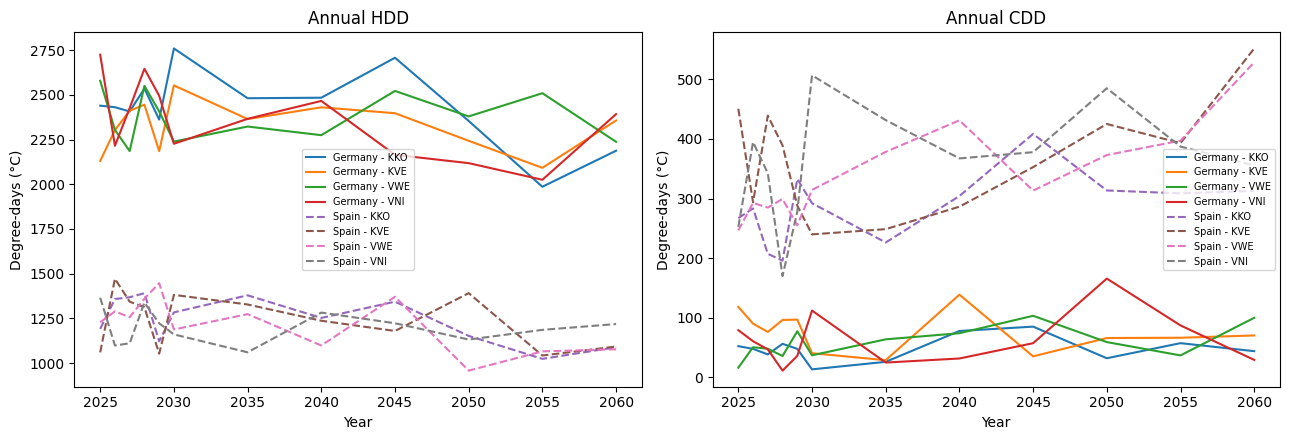

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

CHECK_COUNTRIES = ["Germany", "Spain"]
for country in CHECK_COUNTRIES:
    for scenario in ["KKO", "KVE", "VWE", "VNI"]:
        d = hdd_cdd_scenarios[
            (hdd_cdd_scenarios.country == country) & (hdd_cdd_scenarios.scenario == scenario)
        ].sort_values("year")
        ls = "-" if country == CHECK_COUNTRIES[0] else "--"
        axes[0].plot(d.year, d.hdd_annual, ls, label=f"{country} - {scenario}")
        axes[1].plot(d.year, d.cdd_annual, ls, label=f"{country} - {scenario}")

axes[0].set_title("Annual HDD")
axes[1].set_title("Annual CDD")
for ax in axes:
    ax.set_xlabel("Year")
    ax.set_ylabel("Degree-days (°C)")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()
